# Michelson Interferometer Simulator

Interactive simulation of the interference pattern recorded by a camera in a Michelson interferometer with a **collimated (plane-wave) beam** and a **mirror tilted in two degrees of freedom** (azimuthal `tilt_x`, zenithal `tilt_y`), for **monochromatic** and **broad-spectrum** sources (Taller 3, point 8).

The physics lives in two UI-agnostic modules:

- [`michelson_engine.py`](michelson_engine.py) - interference physics (OPD, intensity, visibility, coherence length).
- [`camera_tools.py`](camera_tools.py) - sensor grid/zoom, perpendicular profile, contrast measurement.

**Kernel:** select **`Python (Optics Michelson)`** (registered from the project `.venv`). See [PLAN.md](PLAN.md) for environment setup.

Core relations (lecture slides, cases c-f):

- Monochromatic: $I = 2 I_0\,[1 + \cos(2 n k_0\,\Delta L)]$, with $k_0 = 2\pi/\lambda$.
- Tilted mirror wedge: $\Delta L(x,y) = \Delta L_0 + \theta_x x + \theta_y y$.
- Broad spectrum: $I = 2 I_0\,[1 + V(\Delta L)\cos(2 n k_0\,\Delta L)]$, rectangular band $V(\Delta L) = |\mathrm{sinc}(n\,\Delta k\,\Delta L)|$.
- Coherence length (round-trip OPD): rectangular $L_c = \lambda^2/\Delta\lambda$; Gaussian $L_c = (2\ln 2/\pi)\,\lambda^2/\Delta\lambda$.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import (
    BoundedFloatText, Dropdown, FloatSlider, HBox, VBox,
    interactive_output, link,
)
from IPython.display import display

import michelson_engine as eng
import camera_tools as cam

# Confirm the correct interpreter / kernel is active and dependencies import.
print("Python:", sys.executable)
for mod in (np, plt.matplotlib, widgets):
    print(f"  {mod.__name__}: {mod.__version__}")
print("Engine + camera modules loaded OK.")

Python: d:\GitHub\Optics\.venv\Scripts\python.exe
  numpy: 2.4.6
  matplotlib: 3.11.0
  ipywidgets: 8.1.8
Engine + camera modules loaded OK.


## 1. Sanity checks

Validate the engine against closed-form expectations before exploring interactively:

1. Monochromatic fringe spacing measured from the simulated image vs $\lambda/(2 n |\theta|)$.
2. Rectangular-spectrum coherence length measured from a visibility sweep vs $\lambda^2/\Delta\lambda$.

In [2]:
from scipy.signal import find_peaks

lam, tilt, sensor = 633e-9, 0.5e-3, 0.01  # 633 nm, 0.5 mrad tilt, 1 cm sensor

# (a) Monochromatic fringe spacing: simulated vs theory
res = 800
_, _, I = cam.simulate_pattern(lam, 0.0, tilt, 0.0, source="mono",
                               sensor_size=sensor, resolution=res)
_, prof = cam.extract_perpendicular_profile(I, tilt, 0.0, n_points=res)
peaks, _ = find_peaks(prof)
px_size = sensor / (res - 1)
ds_meas = np.mean(np.diff(peaks)) * px_size
ds_theory = eng.fringe_spacing(lam, tilt, 0.0)
print(f"(a) fringe spacing  theory={ds_theory*1e6:6.1f} um   measured={ds_meas*1e6:6.1f} um")

# (b) Rectangular-spectrum coherence length: simulated vs theory
dl = 10e-9
dL0 = np.linspace(0, 60e-6, 200)
V = cam.sweep_visibility(dL0, lam, dl, tilt, 0.0, resolution=400, profile="rect")
Lc_meas = cam.measure_coherence_length(dL0, V, method="first_zero")
Lc_theory = eng.coherence_length_theory(lam, dl, "rect")
print(f"(b) coherence Lc    theory={Lc_theory*1e6:6.1f} um   measured={Lc_meas*1e6:6.1f} um")

(a) fringe spacing  theory= 633.0 um   measured= 633.8 um
(b) coherence Lc    theory=  40.1 um   measured=  40.4 um


## 2. Interactive simulator

Move the sliders to explore the camera view and the intensity profile taken **perpendicular to the fringes**. Each numeric control is a **slider + text box** linked together: drag the slider or **type a value** in the box (values are clamped to the allowed range).

| Control | Symbol | Range (default) | Physical meaning |
| --- | --- | --- | --- |
| **lambda (nm)** | $\lambda$ | 400–700 nm (633) | Central vacuum wavelength of the light source. Sets the fringe period and the scale of all optical-path effects. |
| **dlambda (nm)** | $\Delta\lambda$ | 0–200 nm (10) | Spectral width (FWHM) of a broad-band source. Used only when `source = broad`; smaller $\Delta\lambda$ means longer coherence length $L_c \propto \lambda^2/\Delta\lambda$. |
| **dL0 (um)** | $\Delta L_0$ | −60 to +60 µm (0) | Baseline **one-way** arm-length difference between the two interferometer arms (displacement of the movable mirror at the optical axis). Shifts the interference phase globally; for a broad source, increasing $|dL_0|$ reduces fringe contrast until fringes vanish. |
| **tilt_x (mrad)** | $\theta_x$ | −3 to +3 mrad (0.5) | Azimuthal mirror tilt (radians internally). Adds a linear wedge $\theta_x x$ to the local arm difference, producing straight fringes whose spacing is $\Delta s = \lambda/(2n|\theta|)$. Zero tilt with zero $\theta_y$ gives a uniform field (case c). |
| **tilt_y (mrad)** | $\theta_y$ | −3 to +3 mrad (0) | Zenithal mirror tilt. Same role as `tilt_x` but along the other axis; together they set fringe orientation and the combined tilt $|\theta| = \sqrt{\theta_x^2 + \theta_y^2}$ (case d). |
| **zoom** | — | 1–10 (1) | Magnification of the camera sensor about the optical axis. Higher zoom shows a smaller physical area (more detail on individual fringes). |
| **source** | — | `mono` / `broad` | `mono`: monochromatic source, constant fringe contrast (cases c/d). `broad`: finite spectral width with a coherence envelope that damps fringes at large $|dL_0|$ (case f). |
| **spectrum** | — | `rect` / `gaussian` | Spectral line shape when `source = broad`. `rect`: top-hat band → visibility $V = |\mathrm{sinc}(n\Delta k\,\Delta L)|$, first null at $L_c = \lambda^2/\Delta\lambda$. `gaussian`: Gaussian line → Gaussian envelope, 50% visibility at $L_c = (2\ln 2/\pi)\,\lambda^2/\Delta\lambda$. |

**What to try**

- Set `tilt_x = tilt_y = 0`: uniform brightness that changes with `dL0` only (no fringes).
- Set `source = broad` and sweep `dL0`: watch fringes fade as the arm difference exceeds the coherence length.
- Increase `zoom` to inspect fringe spacing and compare with the annotated value on the profile plot.

In [15]:
SENSOR = 0.01   # 1 cm sensor at zoom = 1
RES = 350       # pixels per side (kept modest for live response)


def linked_float(min_val, max_val, step, value, description, text_width="90px"):
    """FloatSlider + BoundedFloatText sharing the same value (slider or keyboard)."""
    slider = FloatSlider(
        min=min_val, max=max_val, step=step, value=value, description=description,
        readout=False, layout=widgets.Layout(width="420px"),
    )
    text = BoundedFloatText(
        min=min_val, max=max_val, step=step, value=value,
        layout=widgets.Layout(width=text_width),
    )
    link((slider, "value"), (text, "value"))
    return slider, HBox([slider, text])


def show_pattern(wavelength_nm=633.0, dlambda_nm=10.0, dL0_um=0.0,
                 tilt_x_mrad=0.5, tilt_y_mrad=0.0, zoom=1.0,
                 source="mono", spectrum="rect"):
    lam = wavelength_nm * 1e-9
    dl = dlambda_nm * 1e-9
    dL0 = dL0_um * 1e-6
    tx, ty = tilt_x_mrad * 1e-3, tilt_y_mrad * 1e-3

    X, Y, I = cam.simulate_pattern(lam, dL0, tx, ty, source=source, dlambda=dl,
                                   profile=spectrum, sensor_size=SENSOR,
                                   resolution=RES, zoom=zoom)
    pos, prof = cam.extract_perpendicular_profile(I, tx, ty, n_points=RES)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    extent = [X.min() * 1e3, X.max() * 1e3, Y.min() * 1e3, Y.max() * 1e3]
    im = ax1.imshow(I, cmap="inferno", extent=extent, origin="lower", vmin=0, vmax=4)
    ax1.set_title("Camera view"); ax1.set_xlabel("x (mm)"); ax1.set_ylabel("y (mm)")
    fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

    ax2.plot(pos, prof, color="C0")
    ax2.set_title("Profile perpendicular to fringes")
    ax2.set_xlabel("position along fringe normal (pixels)")
    ax2.set_ylabel("intensity"); ax2.set_ylim(0, 4.2); ax2.grid(alpha=0.3)

    ds = eng.fringe_spacing(lam, tx, ty)
    info = "no tilt: uniform field" if not np.isfinite(ds) else f"fringe spacing = {ds*1e6:.0f} um"
    if source == "broad":
        Lc = eng.coherence_length_theory(lam, dl, spectrum)
        V_here = (eng.visibility_rect(dL0, lam, dl) if spectrum == "rect"
                  else eng.visibility_gaussian(dL0, lam, dl))
        info += f"\nLc (theory, {spectrum}) = {Lc*1e6:.1f} um\nV(dL0) = {float(V_here):.3f}"
    ax2.text(0.02, 0.97, info, transform=ax2.transAxes, va="top", fontsize=9,
             bbox=dict(boxstyle="round", fc="white", alpha=0.75))
    plt.tight_layout(); plt.show()


# Linked slider + keyboard text box for each numeric parameter
wavelength_nm, wavelength_box = linked_float(400, 5000, 1, 1200, "lambda (nm)")
dlambda_nm, dlambda_box = linked_float(0.0, 200, 0.05, 200, "dlambda (nm)")
dL0_um, dL0_box = linked_float(-60, 60, 0.05, 0.1, "dL0 (um)")
tilt_x_mrad, tilt_x_box = linked_float(-1000, 1000, 0.087, 0, "tilt_x (mrad)")
tilt_y_mrad, tilt_y_box = linked_float(-1000, 1000, 0.087, 0, "tilt_y (mrad)")
zoom, zoom_box = linked_float(-100, 100, 0.5, 1, "zoom")

source = Dropdown(options=["mono", "broad"], value="mono", description="source")
spectrum = Dropdown(options=["rect", "gaussian"], value="rect", description="spectrum")

controls = VBox([
    wavelength_box, dlambda_box, dL0_box,
    tilt_x_box, tilt_y_box, zoom_box,
    source, spectrum,
])

plot_out = interactive_output(
    show_pattern,
    {
        "wavelength_nm": wavelength_nm,
        "dlambda_nm": dlambda_nm,
        "dL0_um": dL0_um,
        "tilt_x_mrad": tilt_x_mrad,
        "tilt_y_mrad": tilt_y_mrad,
        "zoom": zoom,
        "source": source,
        "spectrum": spectrum,
    },
)

display(VBox([controls, plot_out]))

        ## 3. Coherence-length experiment

Sweep the baseline arm difference `dL0`, measure the fringe contrast from each simulated camera frame, and compare the extracted coherence length with theory. This mirrors the lab procedure: move the mirror until the fringes vanish.

- Rectangular spectrum: coherence length read at the **first visibility null**, $L_c = \lambda^2/\Delta\lambda$.
- Gaussian spectrum: read at **50% visibility**, $L_c = (2\ln 2/\pi)\,\lambda^2/\Delta\lambda$.

The horizontal axis is the arm difference `dL0`; the round-trip OPD coherence length is $L_c = 2 n\,\Delta L$, so the markers sit at `Lc / (2n)`.

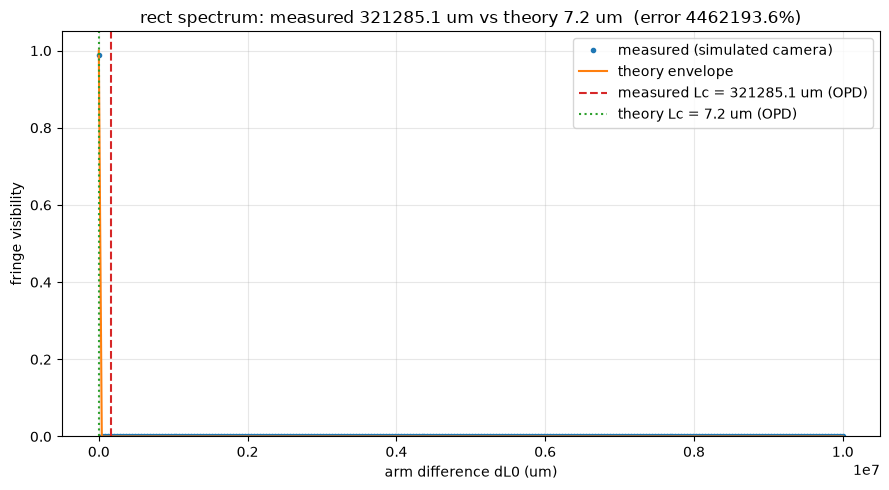

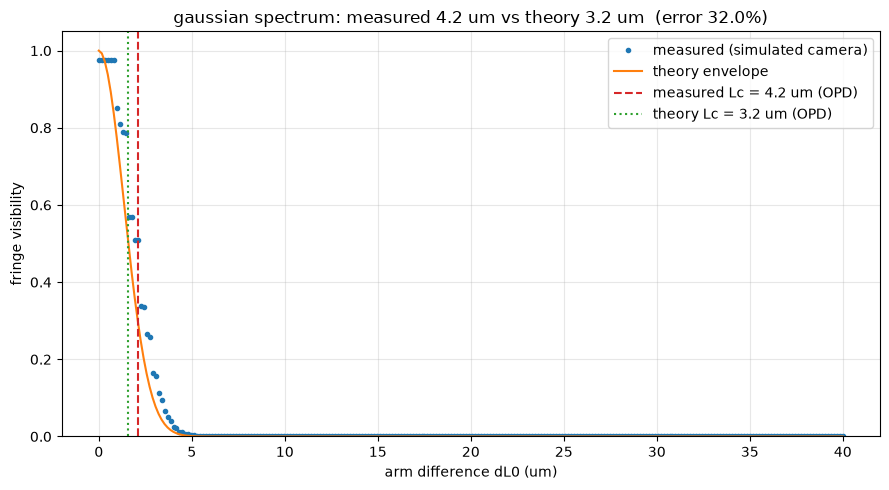

In [18]:
def coherence_experiment(wavelength_nm=1200.0, dlambda_nm=200.0, spectrum="rect",
                         tilt_x_mrad=0.413, n=1.0, max_dL0_um=10000000, n_steps=250):
    lam = wavelength_nm * 1e-9
    dl = dlambda_nm * 1e-9
    tx = tilt_x_mrad * 1e-3

    dL0 = np.linspace(0.0, max_dL0_um * 1e-6, n_steps)
    V_meas = cam.sweep_visibility(dL0, lam, dl, tx, 0.0, n=n,
                                  resolution=400, profile=spectrum)
    V_theory = (eng.visibility_rect(dL0, lam, dl, n=n) if spectrum == "rect"
                else eng.visibility_gaussian(dL0, lam, dl, n=n))

    Lc_theory = eng.coherence_length_theory(lam, dl, spectrum, n=n)
    if spectrum == "rect":
        Lc_meas = cam.measure_coherence_length(dL0, V_meas, n=n, method="first_zero")
    else:
        Lc_meas = cam.measure_coherence_length(dL0, V_meas, n=n,
                                               method="threshold", threshold=0.5)
    err = abs(Lc_meas - Lc_theory) / Lc_theory * 100

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(dL0 * 1e6, V_meas, "o", ms=3, color="C0", label="measured (simulated camera)")
    ax.plot(dL0 * 1e6, V_theory, "-", color="C1", label="theory envelope")
    ax.axvline(Lc_meas / (2 * n) * 1e6, color="C3", ls="--",
               label=f"measured Lc = {Lc_meas*1e6:.1f} um (OPD)")
    ax.axvline(Lc_theory / (2 * n) * 1e6, color="C2", ls=":",
               label=f"theory Lc = {Lc_theory*1e6:.1f} um (OPD)")
    ax.set_xlabel("arm difference dL0 (um)"); ax.set_ylabel("fringe visibility")
    ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.legend(loc="upper right")
    ax.set_title(f"{spectrum} spectrum: measured {Lc_meas*1e6:.1f} um vs "
                 f"theory {Lc_theory*1e6:.1f} um  (error {err:.1f}%)")
    plt.tight_layout(); plt.show()
    return Lc_meas, Lc_theory


_ = coherence_experiment(spectrum="rect")
_ = coherence_experiment(spectrum="gaussian", max_dL0_um=40.0)